In [3]:
import pandas as pd
import numpy as  np

In [4]:
df=pd.read_csv("../data/Scaled_data.csv")

In [5]:
df.columns

Index(['Unnamed: 0', 'specialty', 'gender', 'no_show', 'disability',
       'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'rain_intensity', 'heat_intensity', 'Hipertension', 'Diabetes',
       'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received',
       'place_encoded'],
      dtype='object')

In [6]:
df = df.loc[
    :,
    ~df.columns.str.contains(
        '^Unnamed'
    )
]

In [7]:
df.shape

(109304, 24)

In [8]:
df.columns

Index(['specialty', 'gender', 'no_show', 'disability', 'appointment_shift',
       'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before', 'storm_day_before',
       'rain_intensity', 'heat_intensity', 'Hipertension', 'Diabetes',
       'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received',
       'place_encoded'],
      dtype='object')

This is My Target(No-SHOW) Coloumn For Predictions
Binary Classification

Creating Model 
Logistic Regration ,Randam Forest , XGBoost Classifier,

Evaluate 
Accuracy, Accuracy, F1,Recall,AUC



Step 1: Define X and y
Step 2:split data first(X_train, X_test, y_train, y_test)
step 3:Need Balanced data(SMOTE only on training data)
step 4:Fit Over Model(Train )LogisticRegression,Randam Forest,XGBoost Classifier
Step 5:Predict,probability (important for ROC-AUC)
step 6:Evalutions
step 7:Confusion Matrix
step 8:Classification Report
step 9:ROC-AUC Score,Plot_curve
step 10:compared All the Model (Tables)



In [9]:
df['no_show'].value_counts()

no_show
0    74516
1    34788
Name: count, dtype: int64

In [10]:
#Step 1: Define X and y
X = df.drop('no_show', axis=1)
y = df['no_show']

In [11]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# split data first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: no_show
0    59613
1    27830
Name: count, dtype: int64
After SMOTE: no_show
1    59613
0    59613
Name: count, dtype: int64


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)

model.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
#Predict....
y_pred = model.predict(X_test)

# probability (important for ROC-AUC)
y_proba = model.predict_proba(X_test)[:, 1]

In [14]:
#Accuracy, Precision, Recall, F1 Score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.6174923379534331
Precision: 0.43201626961069145
Recall: 0.6411325093417649
F1 Score: 0.516199953714418


In [15]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[9038 5865]
 [2497 4461]]


In [16]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.61      0.68     14903
           1       0.43      0.64      0.52      6958

    accuracy                           0.62     21861
   macro avg       0.61      0.62      0.60     21861
weighted avg       0.67      0.62      0.63     21861



In [17]:
#ROC-AUC Score
from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.6749557023316266


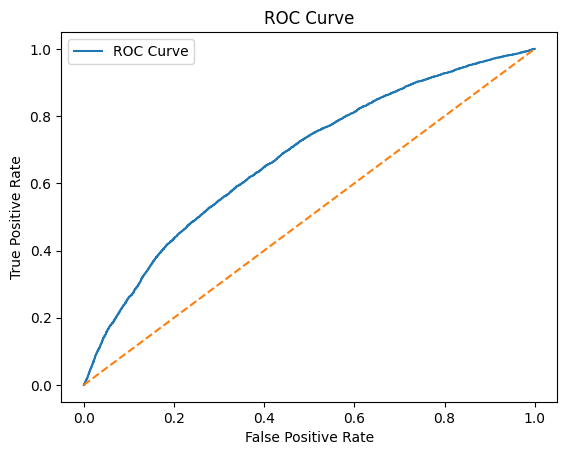

In [18]:
#ROC Curve Plot
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

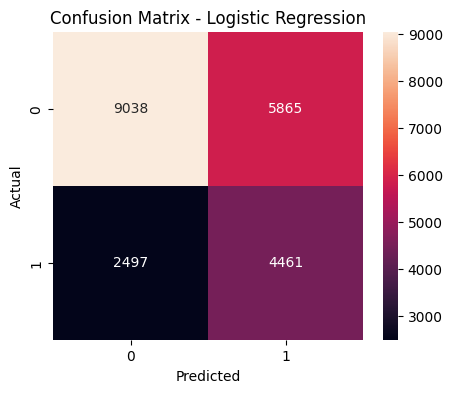

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [20]:
#Split and SMOTE DATA For Random Forest And XGBoost
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [24]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
no_show
0    59613
1    27830
Name: count, dtype: int64

After SMOTE:
no_show
1    59613
0    59613
Name: count, dtype: int64


In [25]:
#RANDOM FOREST (after SMOTE)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"   # optional but useful
)

rf_model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
#Prediction
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [27]:
#Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest Results:
Accuracy: 0.7062805910068158
Precision: 0.5340261056900266
Recall: 0.6056338028169014
F1 Score: 0.5675803084382787
ROC-AUC: 0.7683759596912001


In [28]:
from sklearn.metrics import classification_report

print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf))

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.80      0.75      0.78     14903
           1       0.53      0.61      0.57      6958

    accuracy                           0.71     21861
   macro avg       0.67      0.68      0.67     21861
weighted avg       0.72      0.71      0.71     21861



In [29]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix (Random Forest):")
print(cm_rf)

Confusion Matrix (Random Forest):
[[11226  3677]
 [ 2744  4214]]


In [30]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, y_proba_rf)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.7683759596912001


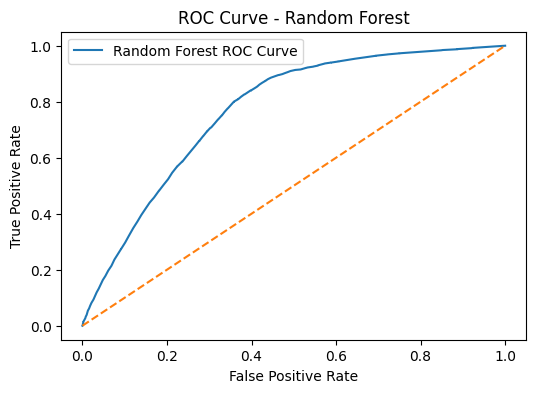

In [31]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label="Random Forest ROC Curve")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

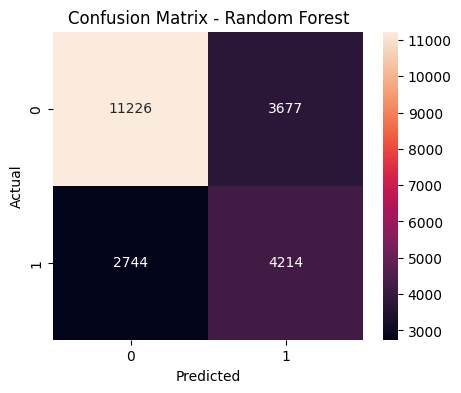

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
#XGBOOST MODEL (BEST FOR IMBALANCED DATA)
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_res, y_train_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [34]:
#Evaluation
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [35]:
#Evaluation
print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

XGBoost Results:
Accuracy: 0.7098485888111248
Precision: 0.534438346959346
Recall: 0.6858292612819776
F1 Score: 0.6007427456410902
ROC-AUC: 0.7642941409155078


In [36]:
from sklearn.metrics import classification_report

print("Classification Report - XGBoost")
print(classification_report(y_test, y_pred_xgb))

Classification Report - XGBoost
              precision    recall  f1-score   support

           0       0.83      0.72      0.77     14903
           1       0.53      0.69      0.60      6958

    accuracy                           0.71     21861
   macro avg       0.68      0.70      0.69     21861
weighted avg       0.74      0.71      0.72     21861



In [37]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix (XGBoost):")
print(cm_xgb)

Confusion Matrix (XGBoost):
[[10746  4157]
 [ 2186  4772]]


In [38]:
y_pred = model.predict(X_test)

tp_data = X_test[(y_test == 1) & (y_pred == 1)]
tn_data = X_test[(y_test == 0) & (y_pred == 0)]
fp_data = X_test[(y_test == 0) & (y_pred == 1)]
fn_data = X_test[(y_test == 1) & (y_pred == 0)]

print("TP:", len(tp_data))
print("TN:", len(tn_data))
print("FP:", len(fp_data))
print("FN:", len(fn_data))

TP: 4461
TN: 9038
FP: 5865
FN: 2497


In [39]:
xgb_auc = roc_auc_score(y_test, y_proba_xgb)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.7642941409155078


In [42]:
y_test.value_counts()

no_show
0    14903
1     6958
Name: count, dtype: int64

In [46]:
y_test

43832    0
73276    0
55566    0
55005    0
13287    0
        ..
3527     1
95306    0
63515    0
93389    0
49573    0
Name: no_show, Length: 21861, dtype: int64

In [43]:
X_test

,specialty,gender,disability,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,...,storm_day_before,rain_intensity,heat_intensity,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,place_encoded
43832,3,1,0,0,-0.474850,1,0,1,-2.601032,-0.854388,...,1,2,0,0,0,0,0,0,0,6018
73276,2,0,1,0,-0.887501,1,0,1,-0.718191,-0.854388,...,1,2,3,0,0,0,0,0,0,31989
55566,7,1,0,0,-0.149507,0,0,0,0.832034,-0.854388,...,1,2,4,0,0,0,0,0,1,31989
55005,5,1,2,1,0.536222,0,0,0,0.401416,0.983830,...,1,2,3,0,0,0,0,0,1,6
13287,2,0,1,1,-1.141945,1,0,1,0.050982,-0.633218,...,1,2,3,0,0,0,0,0,0,5523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3527,4,1,0,1,-1.141945,1,0,1,0.015345,0.930464,...,0,2,1,0,0,0,0,0,0,9
95306,5,1,0,1,-0.887501,1,0,1,-1.392331,-0.633218,...,1,2,3,0,0,0,0,1,0,31989
63515,5,0,0,0,-0.149507,1,0,1,-0.741949,-0.854388,...,1,2,3,0,0,0,0,0,1,9
93389,7,1,0,0,-1.141945,1,0,1,-1.243842,-0.633218,...,1,2,3,0,0,0,0,0,0,2665


In [45]:
X_test.loc[3527]

specialty                  4.000000
gender                     1.000000
disability                 0.000000
appointment_shift          1.000000
age                       -1.141945
under_12_years_old         1.000000
over_60_years_old          0.000000
patient_needs_companion    1.000000
average_temp_day           0.015345
average_rain_day           0.930464
max_temp_day               0.040679
max_rain_day               0.856002
rainy_day_before           0.000000
storm_day_before           0.000000
rain_intensity             2.000000
heat_intensity             1.000000
Hipertension               0.000000
Diabetes                   0.000000
Alcoholism                 0.000000
Handcap                    0.000000
Scholarship                0.000000
SMS_received               0.000000
place_encoded              9.000000
Name: 3527, dtype: float64

In [47]:
X_test.loc[43832]

specialty                     3.000000
gender                        1.000000
disability                    0.000000
appointment_shift             0.000000
age                          -0.474850
under_12_years_old            1.000000
over_60_years_old             0.000000
patient_needs_companion       1.000000
average_temp_day             -2.601032
average_rain_day             -0.854388
max_temp_day                 -1.968761
max_rain_day                 -0.924986
rainy_day_before              1.000000
storm_day_before              1.000000
rain_intensity                2.000000
heat_intensity                0.000000
Hipertension                  0.000000
Diabetes                      0.000000
Alcoholism                    0.000000
Handcap                       0.000000
Scholarship                   0.000000
SMS_received                  0.000000
place_encoded              6018.000000
Name: 43832, dtype: float64

In [44]:
y_test

43832    0
73276    0
55566    0
55005    0
13287    0
        ..
3527     1
95306    0
63515    0
93389    0
49573    0
Name: no_show, Length: 21861, dtype: int64

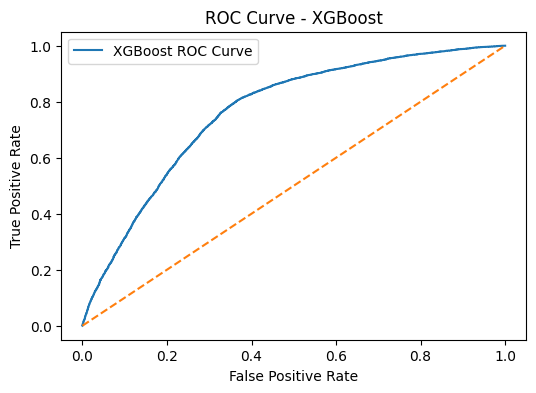

In [66]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(6,4))
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost ROC Curve")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

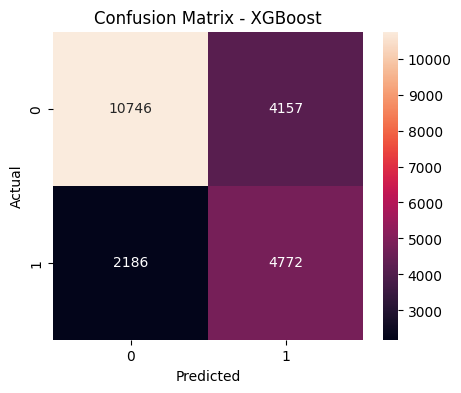

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.617492   0.432016  0.641133  0.516200  0.674956
1        Random Forest  0.706281   0.534026  0.605634  0.567580  0.768376
2              XGBoost  0.709849   0.534438  0.685829  0.600743  0.764294


In [43]:
results.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.706281,0.534026,0.605634,0.567580,0.768376
2,XGBoost,0.709849,0.534438,0.685829,0.600743,0.764294
0,Logistic Regression,0.617492,0.432016,0.641133,0.516200,0.674956


In [44]:
import joblib
joblib.dump(model, "../models/logistic_regression.pkl")

['../models/logistic_regression.pkl']

In [45]:
import joblib
joblib.dump(rf_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [46]:
import joblib
joblib.dump(xgb_model, "../models/xgboost.pkl")

['../models/xgboost.pkl']

In [47]:
xgb_model.feature_names_in_

array(['specialty', 'gender', 'disability', 'appointment_shift', 'age',
       'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity',
       'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship',
       'SMS_received', 'place_encoded'], dtype='<U23')

In [ ]:
print(X.columns)

Index(['specialty', 'gender', 'disability', 'appointment_shift', 'age',
       'under_12_years_old', 'over_60_years_old', 'patient_needs_companion',
       'average_temp_day', 'average_rain_day', 'max_temp_day', 'max_rain_day',
       'rainy_day_before', 'storm_day_before', 'rain_intensity',
       'heat_intensity', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap',
       'Scholarship', 'SMS_received', 'place_encoded'],
      dtype='object')


As Per My Project:---Target: F1-Score > 0.70, ROC-AUC > 0.75

compared Logistic Regression, Random Forest, and XGBoost using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Based on results, XGBoost generally performs best for imbalanced datasets due to gradient boosting optimization.”

| Model               | Accuracy  | Precision | Recall    | F1 Score  | ROC-AUC   |
| ------------------- | --------- | --------- | --------- | --------- | --------- |
| Random Forest       | 0.706     | 0.534     | 0.606     | 0.568     | **0.768** |
| XGBoost             | **0.710** | 0.534     | **0.686** | **0.601** | 0.764     |
| Logistic Regression | 0.617     | 0.432     | 0.641     | 0.516     | 0.675     |



Best Model: XGBoost

 Because:

Highest accuracy
Best recall (important for medical Tabuler DataSet)
Best F1-score (balanced performance)